In [2]:
import numpy as np
import matplotlib.pyplot as plt
import copy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from tensorflow.keras.datasets import mnist

In [1]:
!pip install tensorflow

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [3]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [4]:
class Sequential(Module):
    """
         Этот класс реализует контейнер, который последовательно
         прогоняет вход через все модули из self.modules.
    """

    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Добавляет модуль в контейнер.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        self._inputs = []
        x = input

        for module in self.modules:
            self._inputs.append(x)
            x = module.forward(x)

        self.output = x
        return self.output

    def backward(self, input, gradOutput):
        grad = gradOutput

        for i in range(len(self.modules) - 1, -1, -1):
            grad = self.modules[i].backward(self._inputs[i], grad)

        self.gradInput = grad
        return self.gradInput

## 1. Linear transform layer

`Linear` — это линейный полносвязный слой.

Его также называют:

- dense layer
- fully-connected layer
- FC-layer
- affine transform
- InnerProductLayer (в Caffe)

---

### Что делает слой

Если на вход подаётся матрица объектов `input`, то слой применяет к каждому объекту линейное преобразование:

$$
y = xW^T + b
$$

где:

- $x$ — входной вектор признаков объекта
- $W$ — матрица весов
- $b$ — вектор смещений (`bias`)
- $y$ — выходной вектор

Если батч состоит из нескольких объектов, то формула записывается так же, но уже для всей матрицы:

$$
\text{output} = \text{input} \cdot W^T + b
$$

---

### Размерности

Если

- `input` имеет размер `(batch_size, n_feats1)`

и слой переводит признаки из `n_feats1` в `n_feats2`, тогда:

- `W` имеет размер `(n_feats2, n_feats1)`
- `b` имеет размер `(n_feats2,)`
- `output` имеет размер `(batch_size, n_feats2)`

---


### Прямой проход

На прямом проходе слой вычисляет:

$$
\text{output} = \text{input} \cdot W^T + b
$$

Это и есть основная работа слоя `Linear`.

---

### Обратный проход

Пусть сверху пришёл градиент

$$
\text{gradOutput} = \frac{\partial L}{\partial \text{output}}
$$

Тогда нужно вычислить:

#### Градиент по входу

$$
\text{gradInput} = \text{gradOutput} \cdot W
$$

#### Градиент по весам

$$
\frac{\partial L}{\partial W} = \text{gradOutput}^T \cdot \text{input}
$$

#### Градиент по смещениям

$$
\frac{\partial L}{\partial b} = \sum_{\text{objects in batch}} \text{gradOutput}
$$

То есть по `bias` просто суммируем градиенты по всем объектам батча.

---

### Что хранит слой

Слой `Linear` обычно хранит:

- `W` — матрицу весов
- `b` — вектор смещений
- `gradW` — градиент по весам
- `gradb` — градиент по смещениям

---

### Зачем нужна инициализация

В начале обучения веса нельзя заполнять слишком большими значениями, иначе сеть может обучаться нестабильно.

Поэтому используется небольшая случайная инициализация:

$$
[-\frac{1}{\sqrt{n_{\text{in}}}}, \frac{1}{\sqrt{n_{\text{in}}}}]
$$

Это помогает сделать старт обучения более устойчивым.



In [5]:
class Linear(Module):
    """
    Линейный слой (полносвязный слой).

    Вход:
        input.shape = (batch_size, n_in)

    Выход:
        output.shape = (batch_size, n_out)

    Формула:
        output = input * W^T + b
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # Хорошая инициализация весов
        stdv = 1. / np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size=(n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradW += gradOutput.T @ input
        self.gradb += gradOutput.sum(axis=0)

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' % (s[1], s[0])
        return q

## 2. SoftMax

`SoftMax` преобразует выходы модели в вероятности классов.

### Формула

Для объекта $x = (x_1, x_2, \dots, x_n)$:

$$
\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

После применения `SoftMax`:

- все значения положительные
- сумма значений в каждой строке равна 1

---

### Численная устойчивость

Напрямую считать $e^{x_i}$ бывает опасно, если элементы `input` большие, потому что экспонента может переполниться.

Поэтому используют эквивалентную запись:

$$
\text{softmax}(x)_i =
\frac{e^{x_i - c}}{\sum_{j=1}^{n} e^{x_j - c}}
$$

где обычно берут

$$
c = \max_j x_j
$$

То есть из каждого элемента строки вычитают максимум по этой строке.

Это **не меняет значение softmax**, потому что одинаковый множитель сокращается в числителе и знаменателе:

$$
\frac{e^{x_i-c}}{\sum_j e^{x_j-c}}
=
\frac{e^{x_i}e^{-c}}{e^{-c}\sum_j e^{x_j}}
=
\frac{e^{x_i}}{\sum_j e^{x_j}}
$$

---

### Размерности

Если

- `input` имеет размер `(batch_size, n_feats)`

то и

- `output` имеет размер `(batch_size, n_feats)`

`SoftMax` применяется отдельно к каждой строке батча.

---

### Идея обратного прохода

`SoftMax` нельзя дифференцировать поэлементно независимо, потому что каждый выход зависит от **всех** элементов строки.

Если обозначить:

$$
s = \text{softmax}(x)
$$

то градиент по входу имеет вид:

$$
\frac{\partial L}{\partial x_i}
=
s_i \left(
\frac{\partial L}{\partial s_i}
-
\sum_{k} \frac{\partial L}{\partial s_k} s_k
\right)
$$

В векторном виде для одной строки:

$$
\text{gradInput} =
s \odot \left(\text{gradOutput} - \sum (\text{gradOutput} \odot s)\right)
$$

где $\odot$ — поэлементное умножение.

In [6]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # Нормализация для численной устойчивости:
        # из каждой строки вычитаем максимум
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        exp_input = np.exp(self.output)
        self.output = exp_input / exp_input.sum(axis=1, keepdims=True)

        return self.output

    def updateGradInput(self, input, gradOutput):
        # Для каждого объекта батча:
        # gradInput = softmax * (gradOutput - sum(gradOutput * softmax))
        tmp = np.sum(gradOutput * self.output, axis=1, keepdims=True)
        self.gradInput = self.output * (gradOutput - tmp)

        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. LogSoftMax

`LogSoftMax` — это слой, который применяет логарифм к `SoftMax`.

Он часто используется в задачах классификации, потому что хорошо сочетается с функцией потерь отрицательного логарифма правдоподобия (`NLLLoss`).

---

### Формула

Для объекта $x = (x_1, x_2, \dots, x_n)$:

$$
\text{logsoftmax}(x)_i = \log(\text{softmax}(x)_i)
$$

Так как

$$
\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}},
$$

то

$$
\text{logsoftmax}(x)_i = x_i - \log \sum_{j=1}^{n} e^{x_j}
$$

---

### Размерности

Если

- `input` имеет размер `(batch_size, n_feats)`

то и

- `output` имеет размер `(batch_size, n_feats)`

`LogSoftMax` применяется отдельно к каждой строке батча.

---

### Зачем нужен `LogSoftMax`

Главная цель этого слоя — использовать его при вычислении функции потерь лог-правдоподобия.

Это удобно, потому что:

- `SoftMax` даёт вероятности классов;
- `LogSoftMax` даёт логарифмы этих вероятностей;
- при вычислении loss не нужно отдельно считать `SoftMax`, а потом брать логарифм.

То есть `LogSoftMax` особенно полезен в классификации.

---

### Численная устойчивость

Если считать формулу напрямую, можно получить переполнение из-за экспоненты $e^{x_i}$ при больших значениях `input`.

Поэтому сначала из каждой строки вычитают максимум:

$$
x'_i = x_i - \max_j x_j
$$

Тогда вычисление становится устойчивее:

$$
\text{logsoftmax}(x)_i
=
x'_i - \log \sum_j e^{x'_j}
$$

Это не меняет итоговый результат, но помогает избежать слишком больших чисел внутри `exp`.

---

### Прямой проход

На прямом проходе слой делает следующее:

1. вычитает максимум в каждой строке;
2. считает $\log \sum_j e^{x_j}$;
3. вычитает это значение из каждого элемента строки.

Итог:

$$
\text{output}_i = x_i - \log \sum_j e^{x_j}
$$

---

### Обратный проход

Если обозначить:

$$
y = \text{logsoftmax}(x)
$$

то градиент по входу имеет вид:

$$
\text{gradInput} =
\text{gradOutput}
-
\text{softmax}(x)\cdot \sum_j \text{gradOutput}_j
$$

Так как

$$
\text{softmax}(x) = e^{\text{logsoftmax}(x)},
$$

в реализации можно использовать:

$$
\text{softmax}(x) = e^{\text{output}}
$$

In [7]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        log_sum_exp = np.log(np.exp(self.output).sum(axis=1, keepdims=True))
        self.output = self.output - log_sum_exp

        return self.output

    def updateGradInput(self, input, gradOutput):
        softmax = np.exp(self.output)
        self.gradInput = gradOutput - softmax * gradOutput.sum(axis=1, keepdims=True)

        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. Batch normalization

`BatchNormalization` — это слой, который нормализует признаки внутри батча.

Идея слоя очень важная: если значения признаков на разных слоях сети имеют слишком разные масштабы, обучение становится менее устойчивым и может идти медленнее.  
Поэтому полезно поддерживать признаки в более «нормальном» виде — со средним около 0 и стандартным отклонением около 1.

---

### Основная идея

Для каждого признака внутри текущего батча считаются:

- среднее значение
- дисперсия

После этого признак нормализуется:

$$
y = \frac{x - \mu}{\sqrt{\sigma + \epsilon}}
$$

где:

- $x$ — вход
- $\mu$ — среднее значение признака по батчу
- $\sigma$ — дисперсия признака по батчу
- $\epsilon$ — маленькая константа для численной устойчивости

---

### Размерности

Если

- `input` имеет размер `(batch_size, n_feats)`

то и

- `output` имеет размер `(batch_size, n_feats)`

Нормализация выполняется **по каждому признаку отдельно** на основе всех объектов текущего батча.

---

### Что происходит во время обучения

Если `self.training == True`, то слой:

1. считает среднее по батчу:
   $$
   \mu = \frac{1}{m}\sum_{i=1}^{m} x_i
   $$

2. считает дисперсию по батчу:
   $$
   \sigma = \frac{1}{m}\sum_{i=1}^{m}(x_i - \mu)^2
   $$

3. нормализует вход:
   $$
   y = \frac{x - \mu}{\sqrt{\sigma + \epsilon}}
   $$

4. обновляет скользящие статистики:
   $$
   \text{moving\_mean} = \alpha \cdot \text{moving\_mean} + (1-\alpha)\cdot \text{batch\_mean}
   $$
   $$
   \text{moving\_variance} = \alpha \cdot \text{moving\_variance} + (1-\alpha)\cdot \text{batch\_variance}
   $$

---

### Что происходит во время тестирования

Если `self.training == False`, то статистики текущего батча уже не используются.

Вместо этого слой берёт накопленные значения:

- `moving_mean`
- `moving_variance`

и нормализует вход так:

$$
y = \frac{x - \text{moving\_mean}}{\sqrt{\text{moving\_variance} + \epsilon}}
$$

Это нужно потому, что на тесте модель может обрабатывать даже один объект, и статистики текущего батча уже не будут надёжными.

---

### Зачем нужны moving statistics

Во время обучения батчи разные, поэтому их средние и дисперсии тоже немного отличаются.

Если на тесте брать статистики только из текущего входа, результат будет нестабильным.  
Поэтому во время обучения сохраняются сглаженные значения среднего и дисперсии, которые потом используются на этапе `evaluate()`.

---

### Зачем нужен `EPS`

`EPS` — это маленькое число, которое прибавляется к дисперсии:

$$
\sqrt{\sigma + \epsilon}
$$

Оно нужно, чтобы:

- не делить на ноль;
- избежать численных проблем, если дисперсия очень маленькая.

---

### Важное замечание

В этом задании `BatchNormalization` разбита на две части:

1. **нормализация**
2. **масштабирование и сдвиг** (`ChannelwiseScaling`)

Это сделано для удобства реализации.

Но в общем случае под batch normalization обычно понимают сразу обе части:
- нормализацию,
- а затем обучаемое преобразование вида
  $$
  y = \gamma \hat{x} + \beta
  $$

где:
- $\hat{x}$ — нормализованный вход,
- $\gamma$ — обучаемый масштаб,
- $\beta$ — обучаемый сдвиг.


In [8]:
class BatchNormalization(Module):
    EPS = 1e-3
    def __init__(self, alpha = 0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        if self.moving_mean is None:
            self.moving_mean = np.zeros(input.shape[1], dtype=input.dtype)
            self.moving_variance = np.ones(input.shape[1], dtype=input.dtype)

        if self.training:
            self.batch_mean = np.mean(input, axis=0)
            self.batch_variance = np.var(input, axis=0)

            self.centered_input = input - self.batch_mean
            self.std_inv = 1.0 / np.sqrt(self.batch_variance + self.EPS)
            self.output = self.centered_input * self.std_inv

            self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * self.batch_mean
            self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * self.batch_variance
        else:
            self.output = (input - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size = input.shape[0]

        if not self.training:
            self.gradInput = gradOutput / np.sqrt(self.moving_variance + self.EPS)
            return self.gradInput

        x_mu = self.centered_input
        inv_std = self.std_inv

        sum_grad = np.sum(gradOutput, axis=0)
        sum_grad_xmu = np.sum(gradOutput * x_mu, axis=0)

        self.gradInput = (
            (batch_size * gradOutput - sum_grad - x_mu * (inv_std ** 2) * sum_grad_xmu)
            * inv_std / batch_size
        )

        return self.gradInput

    def __repr__(self):
        return "BatchNormalization"

### ChannelwiseScaling

После нормализации часто добавляют обучаемое преобразование вида:

$$
y = \gamma x + \beta
$$

где:

- $\gamma$ — обучаемый вектор масштабов,
- $\beta$ — обучаемый вектор сдвигов.

Этот слой применяется **по каждому признаку отдельно** и позволяет сети после нормализации заново подобрать удобный масштаб и сдвиг признаков.

Если

- `input` имеет размер `(batch_size, n_feats)`,

то:

- `gamma` имеет размер `(n_feats,)`,
- `beta` имеет размер `(n_feats,)`,
- `output` тоже имеет размер `(batch_size, n_feats)`.

In [9]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta = np.sum(gradOutput, axis=0)
        self.gradGamma = np.sum(gradOutput*input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34508/3092293347.py:3: SyntaxWarning: invalid escape sequence '\g'
  Implements linear transform of input y = \gamma * x + \beta


Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

### Практические замечания

1. Если `BatchNormalization` ставится **после линейного слоя**  
   (например, после `Linear`, `Conv2d`, `ChannelwiseScaling`), который имеет вид

   $$
   y = Wx + b,
   $$

   то смещение `bias` в предыдущем линейном слое часто становится не нужно.

   Почему так происходит:  
   `BatchNormalization` всё равно вычитает среднее по батчу, поэтому эффект от прибавления `bias` затем фактически исчезает.

   Поэтому на практике часто делают так:
   - либо убирают `bias` из линейного слоя,
   - либо просто понимают, что он не очень полезен в такой связке.

---

2. Если `BatchNormalization` (вместе с `ChannelwiseScaling`) стоит **перед слоем, который сохраняет масштаб**,  
   например перед `ReLU` или `LeakyReLU`, а дальше после них идёт линейный слой, то параметр $\gamma$ иногда тоже можно не обучать.

   Причина такая:  
   масштабирование через $\gamma$ можно «поглотить» следующим линейным преобразованием.

   То есть влияние $\gamma$ можно перенести в веса следующего линейного слоя, и отдельная настройка этого параметра становится не обязательной.

## 5. Dropout

`Dropout` — это слой регуляризации, который во время обучения случайно зануляет часть элементов входа.

Идея очень простая: на каждом батче создаётся случайная маска из нулей и единиц, и вход поэлементно умножается на эту маску.

---

### Основная идея

Для каждого элемента входа независимо решается:

- оставить его,
- или занулить.

Если вероятность зануления равна $p$, то маска имеет распределение Бернулли:

$$
m_i \sim \text{Bernoulli}(1-p)
$$

Тогда выход можно записать так:

$$
y_i = x_i \cdot m_i
$$

Но в реализации на обучении обычно используют ещё масштабирование:

$$
y_i = \frac{x_i \cdot m_i}{1-p}
$$

---

### Зачем нужно деление на $(1-p)$

Во время обучения часть элементов зануляется, поэтому среднее значение активаций уменьшается.

Чтобы средние значения на обучении и на тесте были примерно согласованы, оставшиеся элементы дополнительно умножают на

$$
\frac{1}{1-p}
$$

Это называется **inverted dropout**.

Тогда математическое ожидание выхода сохраняется примерно тем же:

$$
\mathbb{E}[y_i] \approx x_i
$$

---

### Размерности

Если

- `input` имеет размер `(batch_size, n_feats)`

то и

- `output` имеет размер `(batch_size, n_feats)`

Маска имеет ту же форму, что и вход.

---

### Что происходит во время обучения

Если `self.training == True`, то слой:

1. генерирует случайную маску;
2. зануляет часть элементов входа;
3. оставшиеся элементы масштабирует на $\frac{1}{1-p}$.

Итоговая формула:

$$
\text{output} = \frac{\text{input} \odot \text{mask}}{1-p}
$$

где:
- $\odot$ — поэлементное умножение,
- `mask` состоит из нулей и единиц.

---

### Что происходит во время тестирования

Если `self.training == False`, то dropout отключается и слой просто ничего не меняет:

$$
\text{output} = \text{input}
$$

То есть на тесте `Dropout` работает как тождественное преобразование.

---

### Зачем нужен `Dropout`

`Dropout` помогает бороться с переобучением.

Интуитивно это работает так:

- сеть не может слишком сильно «привязаться» к конкретным нейронам;
- нейроны вынуждены учиться более устойчивым признакам;
- уменьшается коадаптация нейронов.

Из-за этого модель часто лучше обобщается на новых данных.


In [10]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        if self.training:
            keep_prob = 1.0 - self.p
            self.mask = (np.random.rand(*input.shape) < keep_prob).astype(input.dtype)
            self.output = input * self.mask / keep_prob
        else:
            self.mask = None
            self.output = input.copy()

        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.training:
            keep_prob = 1.0 - self.p
            self.gradInput = gradOutput * self.mask / keep_prob
        else:
            self.gradInput = gradOutput.copy()

        return self.gradInput

    def __repr__(self):
        return "Dropout"

## 6. Conv2d

`Conv2d` — это двумерный сверточный слой, который чаще всего используется для обработки изображений.

Он применяет набор обучаемых фильтров к входным данным и получает карты признаков.

В этом задании нужно реализовать `Conv2d` с параметрами:

- `in_channels`
- `out_channels`
- `kernel_size`
- `stride`
- `padding`
- `bias`
- `padding_mode`

При этом считаем, что:

- `dilation = 1`
- `groups = 1`

---

### Идея слоя

Каждый фильтр «скользит» по входу и на каждом положении считает взвешенную сумму значений из локального окна.

За счёт этого слой умеет находить локальные структуры:
- края,
- текстуры,
- простые паттерны,
- а в глубоких слоях — уже более сложные признаки.

---

### Размерности

Если вход имеет вид

$$
(batch\_size,\ in\_channels,\ height,\ width),
$$

то выход имеет вид

$$
(batch\_size,\ out\_channels,\ out\_height,\ out\_width).
$$

Количество выходных каналов равно числу фильтров.

---

### Параметры слоя

Слой хранит:

- тензор весов свёртки
- при необходимости `bias`

Каждый фильтр имеет размер:

$$
(in\_channels,\ kernel\_height,\ kernel\_width)
$$

А всего фильтров `out_channels`.

### Замечание к реализации `Conv2d`

В этой реализации `Conv2d` слой сделан не только для прямого прохода, но и как **полноценный обучаемый модуль**:

- с весами `weight`,
- со смещением `bias`,
- с градиентами `gradWeight` и `gradBias`,
- с поддержкой `forward`, `backward` и вычисления градиентов по параметрам.

---

### Что внутри важно

#### 1. Padding

Перед свёрткой вход при необходимости дополняется по краям.

Для этого используется метод `_pad_input`, который:
- вычисляет нужные отступы,
- добавляет padding,
- поддерживает разные режимы:
  - `zeros`
  - `reflect`
  - `replicate`

Также поддерживается `padding='same'`, когда размер выхода подбирается автоматически так, чтобы пространственный размер сохранялся максимально близким к исходному.

---

#### 2. Прямой проход

На `forward` слой:

1. дополняет вход,
2. выделяет из него все локальные окна размера `kernel_size`,
3. применяет к ним фильтры,
4. собирает результат в выходной тензор.

Для извлечения окон используется `sliding_window_view`,  
а для быстрого вычисления свёртки — `np.tensordot`.

Это позволяет сделать код заметно эффективнее, чем реализация только через вложенные циклы.

---

#### 3. Обратный проход по входу

При вычислении `gradInput` градиент нужно корректно вернуть обратно к исходному входу.

Для этого:

- сначала считается градиент по дополненному входу (`grad_input_padded`);
- затем `_unpad_grad` переводит его обратно к размеру исходного входа.

Это особенно важно для режимов `reflect` и `replicate`, потому что в них значения на границе не просто обрезаются, а соответствуют отражению или повторению элементов исходного изображения.

---

#### 4. Градиенты по параметрам

Метод `accGradParameters` вычисляет:

- `gradWeight` — градиент по фильтрам,
- `gradBias` — градиент по смещениям.

Градиент по `bias` — это просто сумма `gradOutput` по батчу и пространственным координатам.

Градиент по весам получается суммированием вкладов всех локальных окон входа.

---

### Почему такая реализация считается более сильной

По сравнению с самым простым учебным вариантом через много вложенных циклов, здесь:

- есть поддержка нескольких `padding_mode`,
- корректно реализован `backward`,
- есть градиенты по параметрам,
- используется частичная векторизация (`sliding_window_view`, `tensordot`),
- слой готов к обучению и ближе к реальной библиотечной реализации.

In [11]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size

        if isinstance(stride, int):
            self.stride = (stride, stride)
        else:
            self.stride = stride

        self.padding = padding
        self.use_bias = bias
        self.padding_mode = padding_mode

        kh, kw = self.kernel_size
        stdv = 1.0 / np.sqrt(in_channels * kh * kw)

        self.weight = np.random.uniform(
            -stdv, stdv, size=(out_channels, in_channels, kh, kw)
        )
        self.bias = np.random.uniform(-stdv, stdv, size=out_channels) if bias else None

        self.gradWeight = np.zeros_like(self.weight)
        self.gradBias = np.zeros_like(self.bias) if bias else None

    def _get_padding(self, input_shape):
        _, _, h, w = input_shape
        kh, kw = self.kernel_size
        sh, sw = self.stride

        if self.padding == 'same':
            out_h = int(np.ceil(h / sh))
            out_w = int(np.ceil(w / sw))

            pad_h_total = max((out_h - 1) * sh + kh - h, 0)
            pad_w_total = max((out_w - 1) * sw + kw - w, 0)

            pad_top = pad_h_total // 2
            pad_bottom = pad_h_total - pad_top
            pad_left = pad_w_total // 2
            pad_right = pad_w_total - pad_left

            return pad_top, pad_bottom, pad_left, pad_right

        if isinstance(self.padding, int):
            return self.padding, self.padding, self.padding, self.padding

        if isinstance(self.padding, tuple):
            if len(self.padding) == 2:
                ph, pw = self.padding
                return ph, ph, pw, pw
            if len(self.padding) == 4:
                return self.padding

        raise ValueError("Unsupported padding value")

    def _pad_input(self, input):
        pad_top, pad_bottom, pad_left, pad_right = self._get_padding(input.shape)

        if self.padding_mode == 'zeros':
            mode = 'constant'
            kwargs = {'constant_values': 0}
        elif self.padding_mode == 'reflect':
            mode = 'reflect'
            kwargs = {}
        elif self.padding_mode == 'replicate':
            mode = 'edge'
            kwargs = {}
        else:
            raise ValueError("Unsupported padding_mode")

        padded = np.pad(
            input,
            ((0, 0), (0, 0), (pad_top, pad_bottom), (pad_left, pad_right)),
            mode=mode,
            **kwargs
        )
        return padded, (pad_top, pad_bottom, pad_left, pad_right)

    def _map_index(self, idx, size, pad_before, mode):
        orig = idx - pad_before

        if mode == 'zeros':
            if orig < 0 or orig >= size:
                return None
            return orig

        if mode == 'replicate':
            return min(max(orig, 0), size - 1)

        if mode == 'reflect':
            if size == 1:
                return 0
            while orig < 0 or orig >= size:
                if orig < 0:
                    orig = -orig
                if orig >= size:
                    orig = 2 * size - 2 - orig
            return orig

        raise ValueError("Unsupported padding_mode")

    def _unpad_grad(self, grad_input_padded, input_shape, pads):
        pad_top, pad_bottom, pad_left, pad_right = pads
        n, c, h, w = input_shape
        _, _, h_pad, w_pad = grad_input_padded.shape

        if self.padding_mode == 'zeros':
            h_start = pad_top
            h_end = h_pad - pad_bottom if pad_bottom > 0 else h_pad
            w_start = pad_left
            w_end = w_pad - pad_right if pad_right > 0 else w_pad
            return grad_input_padded[:, :, h_start:h_end, w_start:w_end]

        grad_input = np.zeros((n, c, h, w), dtype=grad_input_padded.dtype)

        for hp in range(h_pad):
            hi = self._map_index(hp, h, pad_top, self.padding_mode)
            if hi is None:
                continue
            for wp in range(w_pad):
                wi = self._map_index(wp, w, pad_left, self.padding_mode)
                if wi is None:
                    continue
                grad_input[:, :, hi, wi] += grad_input_padded[:, :, hp, wp]

        return grad_input

    def updateOutput(self, input):
        from numpy.lib.stride_tricks import sliding_window_view

        padded_input, _ = self._pad_input(input)
        kh, kw = self.kernel_size
        sh, sw = self.stride

        windows = sliding_window_view(padded_input, (kh, kw), axis=(2, 3))
        windows = windows[:, :, ::sh, ::sw, :, :]   # (N, C_in, H_out, W_out, kh, kw)

        out = np.tensordot(
            windows,
            self.weight,
            axes=([1, 4, 5], [1, 2, 3])
        )  # (N, H_out, W_out, C_out)

        self.output = np.transpose(out, (0, 3, 1, 2))

        if self.use_bias:
            self.output += self.bias[None, :, None, None]

        return self.output

    def updateGradInput(self, input, gradOutput):
        padded_input, pads = self._pad_input(input)
        _, _, out_h, out_w = gradOutput.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride

        grad_input_padded = np.zeros_like(padded_input)

        for i in range(kh):
            for j in range(kw):
                contrib = np.tensordot(
                    gradOutput,
                    self.weight[:, :, i, j],
                    axes=([1], [0])
                )  # (N, H_out, W_out, C_in)

                contrib = np.transpose(contrib, (0, 3, 1, 2))  # (N, C_in, H_out, W_out)

                grad_input_padded[:, :, i:i + sh * out_h:sh, j:j + sw * out_w:sw] += contrib

        self.gradInput = self._unpad_grad(grad_input_padded, input.shape, pads)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        from numpy.lib.stride_tricks import sliding_window_view

        padded_input, _ = self._pad_input(input)
        kh, kw = self.kernel_size
        sh, sw = self.stride

        windows = sliding_window_view(padded_input, (kh, kw), axis=(2, 3))
        windows = windows[:, :, ::sh, ::sw, :, :]   # (N, C_in, H_out, W_out, kh, kw)

        for oc in range(self.out_channels):
            self.gradWeight[oc] += np.tensordot(
                gradOutput[:, oc, :, :],
                windows,
                axes=([0, 1, 2], [0, 2, 3])
            )

        if self.use_bias:
            self.gradBias += gradOutput.sum(axis=(0, 2, 3))

    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.use_bias:
            self.gradBias.fill(0)

    def getParameters(self):
        if self.use_bias:
            return [self.weight, self.bias]
        return [self.weight]

    def getGradParameters(self):
        if self.use_bias:
            return [self.gradWeight, self.gradBias]
        return [self.gradWeight]

    def __repr__(self):
        return "Conv2d"

## 7. MaxPool2d и AvgPool2d

`MaxPool2d` и `AvgPool2d` — это двумерные pooling-слои, которые уменьшают пространственный размер карты признаков.

Они не имеют обучаемых параметров, а просто агрегируют значения внутри локальных окон.

В этом задании нужно реализовать:

- `MaxPool2d`
- `AvgPool2d`

с параметрами:

- `kernel_size`
- `stride`
- `padding`

---

### Идея pooling

Pooling-слой берёт локальное окно размера `kernel_size × kernel_size` и заменяет его одним числом.

Это позволяет:

- уменьшить размер признакового пространства;
- снизить вычислительную сложность;
- сделать признаки более устойчивыми к небольшим сдвигам.

---

### MaxPool2d

`MaxPool2d` берёт **максимум** внутри каждого окна:

$$
y = \max(\text{window})
$$

То есть слой оставляет самый сильный отклик в локальной области.

Если используется padding, то за пределами изображения берётся значение

$$
-\infty
$$

чтобы фиктивные элементы не становились максимумом.

---

### AvgPool2d

`AvgPool2d` берёт **среднее значение** внутри каждого окна:

$$
y = \frac{1}{k_h k_w} \sum \text{window}
$$

То есть слой усредняет значения в локальной области.

Если используется padding, то за пределами изображения берутся нули.

---

### Размерности

Если вход имеет вид

$$
(batch\_size,\ channels,\ height,\ width),
$$

то выход имеет вид

$$
(batch\_size,\ channels,\ out\_height,\ out\_width).
$$

Pooling выполняется **отдельно по каждому каналу**.

---

### Обратный проход

#### Для `MaxPool2d`

Градиент передаётся **только в ту позицию окна, где был максимум**.

Если максимумов несколько, обычно градиент отправляют в одну из них согласно выбранной реализации.

#### Для `AvgPool2d`

Градиент равномерно распределяется между всеми элементами окна:

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{1}{k_h k_w}
$$

In [12]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size

        if isinstance(stride, int):
            self.stride = (stride, stride)
        else:
            self.stride = stride

        if isinstance(padding, int):
            self.padding = (padding, padding)
        else:
            self.padding = padding

        self.max_indices = None

    def updateOutput(self, input):
        batch_size, channels, h_in, w_in = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        padded_input = np.pad(
            input,
            ((0, 0), (0, 0), (ph, ph), (pw, pw)),
            mode='constant',
            constant_values=-np.inf
        )

        h_out = (h_in + 2 * ph - kh) // sh + 1
        w_out = (w_in + 2 * pw - kw) // sw + 1

        self.output = np.zeros((batch_size, channels, h_out, w_out))
        self.max_indices = np.zeros((batch_size, channels, h_out, w_out, 2), dtype=int)

        for n in range(batch_size):
            for c in range(channels):
                for i in range(h_out):
                    for j in range(w_out):
                        h_start = i * sh
                        h_end = h_start + kh
                        w_start = j * sw
                        w_end = w_start + kw

                        window = padded_input[n, c, h_start:h_end, w_start:w_end]
                        flat_idx = np.argmax(window)
                        max_pos = np.unravel_index(flat_idx, window.shape)

                        self.output[n, c, i, j] = window[max_pos]
                        self.max_indices[n, c, i, j] = (h_start + max_pos[0], w_start + max_pos[1])

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, channels, h_in, w_in = input.shape
        ph, pw = self.padding
        h_pad = h_in + 2 * ph
        w_pad = w_in + 2 * pw

        self.gradInput = np.zeros((batch_size, channels, h_pad, w_pad))

        h_out, w_out = gradOutput.shape[2], gradOutput.shape[3]

        for n in range(batch_size):
            for c in range(channels):
                for i in range(h_out):
                    for j in range(w_out):
                        h_idx, w_idx = self.max_indices[n, c, i, j]
                        self.gradInput[n, c, h_idx, w_idx] += gradOutput[n, c, i, j]

        if ph == 0 and pw == 0:
            return self.gradInput

        self.gradInput = self.gradInput[:, :, ph:ph + h_in, pw:pw + w_in]
        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"


class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size

        if isinstance(stride, int):
            self.stride = (stride, stride)
        else:
            self.stride = stride

        if isinstance(padding, int):
            self.padding = (padding, padding)
        else:
            self.padding = padding

    def updateOutput(self, input):
        batch_size, channels, h_in, w_in = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        padded_input = np.pad(
            input,
            ((0, 0), (0, 0), (ph, ph), (pw, pw)),
            mode='constant',
            constant_values=0
        )

        h_out = (h_in + 2 * ph - kh) // sh + 1
        w_out = (w_in + 2 * pw - kw) // sw + 1

        self.output = np.zeros((batch_size, channels, h_out, w_out))

        for n in range(batch_size):
            for c in range(channels):
                for i in range(h_out):
                    for j in range(w_out):
                        h_start = i * sh
                        h_end = h_start + kh
                        w_start = j * sw
                        w_end = w_start + kw

                        window = padded_input[n, c, h_start:h_end, w_start:w_end]
                        self.output[n, c, i, j] = np.mean(window)

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, channels, h_in, w_in = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        h_pad = h_in + 2 * ph
        w_pad = w_in + 2 * pw

        self.gradInput = np.zeros((batch_size, channels, h_pad, w_pad))

        h_out, w_out = gradOutput.shape[2], gradOutput.shape[3]
        scale = 1.0 / (kh * kw)

        for n in range(batch_size):
            for c in range(channels):
                for i in range(h_out):
                    for j in range(w_out):
                        h_start = i * sh
                        h_end = h_start + kh
                        w_start = j * sw
                        w_end = w_start + kw

                        self.gradInput[n, c, h_start:h_end, w_start:w_end] += gradOutput[n, c, i, j] * scale

        if ph == 0 and pw == 0:
            return self.gradInput

        self.gradInput = self.gradInput[:, :, ph:ph + h_in, pw:pw + w_in]
        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"

## 8. GlobalMaxPool2d и GlobalAvgPool2d

`GlobalMaxPool2d` и `GlobalAvgPool2d` — это глобальные pooling-слои.

В отличие от обычного pooling, они агрегируют информацию не в маленьком окне, а **сразу по всей пространственной карте каждого канала**.

---

### Идея слоя

Пусть вход имеет размер

$$
(batch\_size,\ channels,\ height,\ width)
$$

Тогда для каждого объекта и каждого канала весь массив размера `height × width` сворачивается в **одно число**.

---

### GlobalMaxPool2d

`GlobalMaxPool2d` берёт максимум по всем пространственным координатам внутри канала:

$$
y_{n,c} = \max_{h,w} x_{n,c,h,w}
$$

То есть каждый канал заменяется своим максимальным значением.

---

### GlobalAvgPool2d

`GlobalAvgPool2d` берёт среднее по всем пространственным координатам внутри канала:

$$
y_{n,c} = \frac{1}{H \cdot W} \sum_{h,w} x_{n,c,h,w}
$$

То есть каждый канал заменяется средним значением.

---

### Размерности

Если вход имеет вид

$$
(batch\_size,\ channels,\ height,\ width),
$$

то естественный выход имеет вид

$$
(batch\_size,\ channels).
$$

То есть для каждого объекта и каждого канала остаётся одно итоговое число.

---

### Обратный проход

#### Для `GlobalMaxPool2d`

Градиент передаётся только в ту позицию, где находился максимум внутри канала.

#### Для `GlobalAvgPool2d`

Градиент равномерно распределяется по всем элементам канала:

$$
\frac{\partial L}{\partial x_{n,c,h,w}} =
\frac{1}{H \cdot W}\frac{\partial L}{\partial y_{n,c}}
$$


In [13]:
class GlobalMaxPool2d(Module):
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()
        self.max_indices = None
        self.input_shape = None

    def updateOutput(self, input):
        self.input_shape = input.shape
        batch_size, channels, height, width = input.shape

        reshaped = input.reshape(batch_size, channels, -1)
        self.output = np.max(reshaped, axis=2)
        self.max_indices = np.argmax(reshaped, axis=2)

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, channels, height, width = input.shape
        self.gradInput = np.zeros_like(input)

        for n in range(batch_size):
            for c in range(channels):
                idx = self.max_indices[n, c]
                h = idx // width
                w = idx % width
                self.gradInput[n, c, h, w] += gradOutput[n, c]

        return self.gradInput

    def __repr__(self):
        return "GlobalMaxPool2d"


class GlobalAvgPool2d(Module):
    def __init__(self):
        super(GlobalAvgPool2d, self).__init__()

    def updateOutput(self, input):
        self.output = np.mean(input, axis=(2, 3))
        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, channels, height, width = input.shape
        self.gradInput = np.zeros_like(input)

        scale = 1.0 / (height * width)
        self.gradInput = gradOutput[:, :, None, None] * scale * np.ones_like(input)

        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"


def test_GlobalMaxPool2d():
    layer = GlobalMaxPool2d()

    x = np.array([[
        [[1., 5.],
         [2., 3.]],
        [[4., 0.],
         [7., 6.]]
    ]])  # shape = (1, 2, 2, 2)

    out = layer.forward(x)
    expected_out = np.array([[5., 7.]])
    assert np.allclose(out, expected_out), f"GlobalMaxPool2d forward failed: {out} != {expected_out}"

    grad_out = np.array([[10., 20.]])
    grad_in = layer.backward(x, grad_out)

    expected_grad = np.array([[
        [[0., 10.],
         [0., 0.]],
        [[0., 0.],
         [20., 0.]]
    ]])

    assert np.allclose(grad_in, expected_grad), f"GlobalMaxPool2d backward failed: {grad_in} != {expected_grad}"
    print("GlobalMaxPool2d tests passed!")


def test_GlobalAvgPool2d():
    layer = GlobalAvgPool2d()

    x = np.array([[
        [[1., 5.],
         [2., 3.]],
        [[4., 0.],
         [7., 6.]]
    ]])  # shape = (1, 2, 2, 2)

    out = layer.forward(x)
    expected_out = np.array([[(1. + 5. + 2. + 3.) / 4, (4. + 0. + 7. + 6.) / 4]])
    assert np.allclose(out, expected_out), f"GlobalAvgPool2d forward failed: {out} != {expected_out}"

    grad_out = np.array([[8., 12.]])
    grad_in = layer.backward(x, grad_out)

    expected_grad = np.array([[
        [[2., 2.],
         [2., 2.]],
        [[3., 3.],
         [3., 3.]]
    ]])

    assert np.allclose(grad_in, expected_grad), f"GlobalAvgPool2d backward failed: {grad_in} != {expected_grad}"
    print("GlobalAvgPool2d tests passed!")


test_GlobalMaxPool2d()
test_GlobalAvgPool2d()

GlobalMaxPool2d tests passed!
GlobalAvgPool2d tests passed!


#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

## Flatten

`Flatten` — это слой, который меняет форму тензора, объединяя несколько соседних измерений в одно.

Он не меняет сами данные, а только преобразует их размерность.

Обычно `Flatten` используют перед полносвязным слоем, чтобы превратить многомерный вход в двумерный.

In [14]:
class Flatten(Module):
    def __init__(self, start_dim=0, end_dim=-1):
        super(Flatten, self).__init__()

        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        ndim = input.ndim

        start_dim = self.start_dim if self.start_dim >= 0 else self.start_dim + ndim
        end_dim = self.end_dim if self.end_dim >= 0 else self.end_dim + ndim

        new_shape = (
            input.shape[:start_dim]
            + (int(np.prod(input.shape[start_dim:end_dim + 1])),)
            + input.shape[end_dim + 1:]
        )

        self.output = input.reshape(new_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(input.shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

### ReLU


$$
\text{ReLU}(x) = \max(0, x)
$$

То есть:

- если $x > 0$, значение остаётся без изменений;
- если $x \le 0$, результат равен 0.

На обратном проходе градиент проходит только через положительные элементы входа.

In [15]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

## LeakyReLU

`LeakyReLU` — это модификация `ReLU`, в которой отрицательные значения не зануляются полностью, а умножаются на маленький коэффициент `slope`.

Функция задаётся так:

$$
\text{LeakyReLU}(x) =
\begin{cases}
x, & x \ge 0 \\
\text{slope} \cdot x, & x < 0
\end{cases}
$$

Идея слоя: оставить небольшой градиент и для отрицательных входов, чтобы нейрон не “умирал”, как это может происходить в обычном `ReLU`.

In [16]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        self.output = np.where(input >= 0, input, self.slope * input)
        return self.output

    def updateGradInput(self, input, gradOutput):
        derivative = np.where(input >= 0, 1.0, self.slope)
        self.gradInput = gradOutput * derivative
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

## ELU

`ELU` (`Exponential Linear Unit`) — это функция активации, которая ведёт себя линейно на положительных значениях и экспоненциально на отрицательных.

Она задаётся формулой:

$$
\text{ELU}(x) =
\begin{cases}
x, & x \ge 0 \\
\alpha (e^x - 1), & x < 0
\end{cases}
$$

Здесь $\alpha > 0$ — параметр, который задаёт масштаб отрицательной части.

Идея `ELU`: как и у `LeakyReLU`, сохранить градиент для отрицательных значений, но сделать это более плавно.

In [17]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        self.output = np.where(input >= 0, input, self.alpha * (np.exp(input) - 1))
        return self.output

    def updateGradInput(self, input, gradOutput):
        derivative = np.where(input >= 0, 1.0, self.alpha * np.exp(input))
        self.gradInput = gradOutput * derivative
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

## SoftPlus

`SoftPlus` — это гладкая версия `ReLU`.

Она задаётся формулой:

$$
\text{SoftPlus}(x) = \log(1 + e^x)
$$

На больших положительных значениях `SoftPlus` ведёт себя почти как `ReLU`,  
а на отрицательных — плавно приближается к нулю.

Главное отличие от `ReLU`: функция `SoftPlus` гладкая, то есть не имеет излома в нуле.

In [18]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        self.output = np.log1p(np.exp(-np.abs(input))) + np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        sigmoid = 1.0 / (1.0 + np.exp(-input))
        self.gradInput = gradOutput * sigmoid
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

## GELU

`GELU` (`Gaussian Error Linear Unit`) — это гладкая функция активации, которая используется, например, в трансформерах.

Она задаётся формулой:

$$
\text{GELU}(x) = x \Phi(x)
$$

где $\Phi(x)$ — функция распределения стандартного нормального закона.

На практике часто используют приближение:

$$
\text{GELU}(x) \approx 0.5x \left(1 + \tanh\left(\sqrt{\frac{2}{\pi}}\left(x + 0.044715x^3\right)\right)\right)
$$

`GELU` ведёт себя мягче, чем `ReLU`: он не просто обнуляет отрицательные значения, а плавно ослабляет их.

In [19]:
class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        self.input = input
        c = np.sqrt(2.0 / np.pi)
        u = c * (input + 0.044715 * input ** 3)
        self.tanh_u = np.tanh(u)

        self.output = 0.5 * input * (1.0 + self.tanh_u)
        return self.output

    def updateGradInput(self, input, gradOutput):
        c = np.sqrt(2.0 / np.pi)
        u = c * (input + 0.044715 * input ** 3)
        tanh_u = np.tanh(u)

        du_dx = c * (1.0 + 3.0 * 0.044715 * input ** 2)
        derivative = 0.5 * (1.0 + tanh_u) + 0.5 * input * (1.0 - tanh_u ** 2) * du_dx

        self.gradInput = gradOutput * derivative
        return self.gradInput

    def __repr__(self):
        return "Gelu"

## Criterion

`Criterion` — это базовый класс для функций потерь.

Функция потерь получает:

- `input` — предсказания модели,
- `target` — правильные ответы,

и возвращает одно число — значение ошибки.

Также criterion должен уметь вычислять градиент функции потерь по входу, чтобы затем можно было запустить обратное распространение ошибки.

Как и `Module`, этот класс является базовым шаблоном: конкретные функции потерь будут наследоваться от него и реализовывать свои `updateOutput` и `updateGradInput`.

In [20]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

## MSECriterion

`MSECriterion` — это функция потерь среднеквадратичной ошибки (`Mean Squared Error`).

Она сравнивает предсказания модели с правильными ответами и вычисляет средний квадрат разности:

$$
\text{MSE} = \frac{1}{N}\sum (input - target)^2
$$

где $N$ — число объектов в батче

In [21]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. ClassNLLCriterionUnstable

`ClassNLLCriterionUnstable` — это функция потерь для многоклассовой классификации, когда на вход уже подаются **вероятности классов**.

Если `target` задан в one-hot виде, то в каждой строке только один правильный класс равен 1, а остальные 0.  
Поэтому функция потерь упрощается: для каждого объекта нужно взять только вероятность правильного класса и посчитать её отрицательный логарифм.

Формула для батча:

$$
L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{j=1}^{C} target_{ij}\log(input_{ij})
$$

где:
- $N$ — размер батча,
- $C$ — число классов.

Чтобы избежать вычисления $\log(0)$, вероятности перед вычислением ограничивают снизу и сверху с помощью маленького числа `EPS`.


In [22]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        self.output = -np.sum(target * np.log(input_clamp)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        self.gradInput = -target / input_clamp / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. ClassNLLCriterion

`ClassNLLCriterion` — это устойчивая версия функции отрицательного логарифма правдоподобия для многоклассовой классификации.

В отличие от предыдущего варианта, на вход здесь подаются не вероятности, а **логарифмы вероятностей** (`log probabilities`), например после слоя `LogSoftMax`.

Если `target` задан в one-hot виде, то функция потерь для батча записывается так:

$$
L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{j=1}^{C} target_{ij}\, input_{ij}
$$

где:
- $N$ — размер батча,
- $C$ — число классов,
- `input` — логарифмы вероятностей.

Такая реализация численно устойчивее, потому что не нужно отдельно вычислять `log` от вероятностей.

In [23]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = -np.sum(target * input) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput = -target / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.
6. Свитч лося (метрики) и оптимайзера.

## Служебные функции
В этом блоке собраны вспомогательные функции:
- получение всех модулей и параметров модели;
- переключение train/eval;
- обнуление градиентов;
- сохранение и загрузка лучших параметров;
- генерация минибатчей;
- метрики качества.

In [24]:
def get_all_modules(module):
    modules = [module]
    if hasattr(module, 'modules'):
        for submodule in module.modules:
            modules.extend(get_all_modules(submodule))
    return modules


def get_all_parameters(model):
    params = []
    grads = []

    for module in get_all_modules(model):
        if hasattr(module, 'getParameters') and hasattr(module, 'getGradParameters'):
            module_params = module.getParameters()
            module_grads = module.getGradParameters()

            if module_params is not None and module_grads is not None:
                for p, g in zip(module_params, module_grads):
                    params.append(p)
                    grads.append(g)

    return params, grads


def zero_grad(model):
    for module in get_all_modules(model):
        if hasattr(module, 'zeroGradParameters'):
            module.zeroGradParameters()


def set_train(model):
    for module in get_all_modules(model):
        module.train()


def set_eval(model):
    for module in get_all_modules(model):
        module.evaluate()


def save_parameters(model):
    params, _ = get_all_parameters(model)
    return [p.copy() for p in params]


def load_parameters(model, saved_params):
    params, _ = get_all_parameters(model)
    for p, sp in zip(params, saved_params):
        p[...] = sp


def iterate_minibatches(X, y=None, batch_size=64, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)

    for start_idx in range(0, len(X), batch_size):
        batch_idx = indices[start_idx:start_idx + batch_size]
        if y is None:
            yield X[batch_idx]
        else:
            yield X[batch_idx], y[batch_idx]


def iterate_minibatches_classification(X, y, y_onehot, batch_size=64, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)

    for start_idx in range(0, len(X), batch_size):
        batch_idx = indices[start_idx:start_idx + batch_size]
        yield X[batch_idx], y[batch_idx], y_onehot[batch_idx]


def one_hot_encode(y, num_classes):
    y = y.astype(int)
    out = np.zeros((len(y), num_classes))
    out[np.arange(len(y)), y] = 1.0
    return out


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def accuracy_score_np(y_true, y_pred_logits):
    y_pred = np.argmax(y_pred_logits, axis=1)
    return np.mean(y_true == y_pred)

## Оптимизаторы и регуляризация обучения
В этом блоке реализованы:
- SGD с momentum;
- Adam;
- warmup scheduler;
- уменьшение learning rate при ухудшении валидации;
- early stopping;
- функция построения графиков.

In [25]:
class SGDOptimizer:
    def __init__(self, model, lr=1e-2, momentum=0.0, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay

        params, _ = get_all_parameters(model)
        self.velocity = [np.zeros_like(p) for p in params]

    def step(self):
        params, grads = get_all_parameters(self.model)

        for i, (p, g) in enumerate(zip(params, grads)):
            grad = g.copy()

            if self.weight_decay > 0:
                grad += self.weight_decay * p

            if self.momentum > 0:
                self.velocity[i] = self.momentum * self.velocity[i] - self.lr * grad
                p += self.velocity[i]
            else:
                p -= self.lr * grad


class AdamOptimizer:
    def __init__(self, model, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0

        params, _ = get_all_parameters(model)
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]

    def step(self):
        self.t += 1
        params, grads = get_all_parameters(self.model)

        for i, (p, g) in enumerate(zip(params, grads)):
            grad = g.copy()

            if self.weight_decay > 0:
                grad += self.weight_decay * p

            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad ** 2)

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


class WarmupScheduler:
    def __init__(self, optimizer, warmup_epochs=5, target_lr=1e-3):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.target_lr = target_lr

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            self.optimizer.lr = self.target_lr * (epoch + 1) / self.warmup_epochs


class ReduceLROnPlateau:
    def __init__(self, optimizer, factor=0.5, patience=3, min_lr=1e-5):
        self.optimizer = optimizer
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr

        self.best = np.inf
        self.bad_epochs = 0

    def step(self, current_value):
        if current_value < self.best:
            self.best = current_value
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1
            if self.bad_epochs >= self.patience:
                self.optimizer.lr = max(self.optimizer.lr * self.factor, self.min_lr)
                self.bad_epochs = 0


class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.counter = 0
        self.best_params = None

    def step(self, current_value, model):
        if current_value < self.best - self.min_delta:
            self.best = current_value
            self.counter = 0
            self.best_params = save_parameters(model)
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


def plot_history(history, title='Training history'):
    epochs = np.arange(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(title + ' - loss')
    plt.legend()

    metric_names = []
    for k in history.keys():
        if k.startswith('train_') and k != 'train_loss':
            metric_names.append(k.replace('train_', ''))

    if len(metric_names) > 0:
        metric_name = metric_names[0]

        plt.subplot(1, 2, 2)
        plt.plot(epochs, history[f'train_{metric_name}'], label=f'train_{metric_name}')
        plt.plot(epochs, history[f'val_{metric_name}'], label=f'val_{metric_name}')
        plt.xlabel('epoch')
        plt.ylabel(metric_name)
        plt.title(title + f' - {metric_name}')
        plt.legend()

    plt.show()

## Функции обучения
Здесь реализованы универсальные train/eval-функции:
- для регрессии;
- для классификации.
Они используются дальше во всех моделях второй части.

In [26]:
def train_epoch_regression(model, criterion, optimizer, X, y, batch_size=64):
    set_train(model)

    total_loss = 0.0
    preds_all = []
    targets_all = []

    for X_batch, y_batch in iterate_minibatches(X, y, batch_size=batch_size, shuffle=True):
        zero_grad(model)

        output = model.forward(X_batch)
        loss = criterion.forward(output, y_batch)
        grad_loss = criterion.backward(output, y_batch)
        model.backward(X_batch, grad_loss)
        optimizer.step()

        total_loss += loss * len(X_batch)
        preds_all.append(output)
        targets_all.append(y_batch)

    preds_all = np.vstack(preds_all)
    targets_all = np.vstack(targets_all)

    epoch_loss = total_loss / len(X)
    epoch_rmse = rmse(targets_all, preds_all)

    return epoch_loss, epoch_rmse


def evaluate_regression(model, criterion, X, y, batch_size=64):
    set_eval(model)

    total_loss = 0.0
    preds_all = []
    targets_all = []

    for X_batch, y_batch in iterate_minibatches(X, y, batch_size=batch_size, shuffle=False):
        output = model.forward(X_batch)
        loss = criterion.forward(output, y_batch)

        total_loss += loss * len(X_batch)
        preds_all.append(output)
        targets_all.append(y_batch)

    preds_all = np.vstack(preds_all)
    targets_all = np.vstack(targets_all)

    epoch_loss = total_loss / len(X)
    epoch_rmse = rmse(targets_all, preds_all)

    return epoch_loss, epoch_rmse


def train_epoch_classification(model, criterion, optimizer, X, y, y_onehot, batch_size=64):
    set_train(model)

    total_loss = 0.0
    logits_all = []
    labels_all = []

    for X_batch, y_batch, y_batch_oh in iterate_minibatches_classification(X, y, y_onehot, batch_size=batch_size):
        zero_grad(model)

        output = model.forward(X_batch)
        loss = criterion.forward(output, y_batch_oh)
        grad_loss = criterion.backward(output, y_batch_oh)
        model.backward(X_batch, grad_loss)
        optimizer.step()

        total_loss += loss * len(X_batch)
        logits_all.append(output)
        labels_all.append(y_batch)

    logits_all = np.vstack(logits_all)
    labels_all = np.concatenate(labels_all)

    epoch_loss = total_loss / len(X)
    epoch_acc = accuracy_score_np(labels_all, logits_all)

    return epoch_loss, epoch_acc


def evaluate_classification(model, criterion, X, y, y_onehot, batch_size=64):
    set_eval(model)

    total_loss = 0.0
    logits_all = []
    labels_all = []

    for X_batch, y_batch, y_batch_oh in iterate_minibatches_classification(
        X, y, y_onehot, batch_size=batch_size, shuffle=False
    ):
        output = model.forward(X_batch)
        loss = criterion.forward(output, y_batch_oh)

        total_loss += loss * len(X_batch)
        logits_all.append(output)
        labels_all.append(y_batch)

    logits_all = np.vstack(logits_all)
    labels_all = np.concatenate(labels_all)

    epoch_loss = total_loss / len(X)
    epoch_acc = accuracy_score_np(labels_all, logits_all)

    return epoch_loss, epoch_acc

## Мультирегрессия
В этом блоке:
- загружаются данные California Housing;
- данные делятся на train/val/test;
- признаки и таргет нормализуются;
- задается функция построения FCNN-модели разных размеров.

In [27]:
housing = fetch_california_housing()
X = housing.data.astype(np.float32)
y = housing.target.astype(np.float32).reshape(-1, 1)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train).astype(np.float32)
X_val = x_scaler.transform(X_val).astype(np.float32)
X_test = x_scaler.transform(X_test).astype(np.float32)

y_train = y_scaler.fit_transform(y_train).astype(np.float32)
y_val = y_scaler.transform(y_val).astype(np.float32)
y_test = y_scaler.transform(y_test).astype(np.float32)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(14912, 8) (2632, 8) (3096, 8)
(14912, 1) (2632, 1) (3096, 1)


In [28]:
def get_activation(name):
    name = name.lower()
    if name == 'relu':
        return ReLU()
    elif name == 'leakyrelu':
        return LeakyReLU()
    elif name == 'elu':
        return ELU()
    elif name == 'softplus':
        return SoftPlus()
    elif name == 'gelu':
        return Gelu()
    else:
        raise ValueError(f'Unknown activation: {name}')


def make_regression_model(size='small', activation='relu', input_dim=8, output_dim=1):
    model = Sequential()

    if size == 'small':
        hidden = [64, 32]
    elif size == 'medium':
        hidden = [128, 64, 32]
    elif size == 'large':
        hidden = [256, 128, 64, 32]
    else:
        raise ValueError("size must be: 'small', 'medium' or 'large'")

    dims = [input_dim] + hidden

    for i in range(len(hidden)):
        model.add(Linear(dims[i], dims[i + 1]))
        model.add(BatchNormalization(alpha=0.9))
        model.add(ChannelwiseScaling(dims[i + 1]))
        model.add(get_activation(activation))
        model.add(Dropout(p=0.2))

    model.add(Linear(hidden[-1], output_dim))
    return model

## Обучение моделей для мультирегрессии
В этом блоке задается функция обучения модели и обучаются три варианта сети:
- small;
- medium;
- large.
После обучения строятся графики и считается качество на тесте.

In [29]:
def fit_regression_model(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=40,
    batch_size=64,
    optimizer_name='adam',
    lr=1e-3
):
    criterion = MSECriterion()

    if optimizer_name.lower() == 'adam':
        optimizer = AdamOptimizer(model, lr=lr, weight_decay=1e-4)
    else:
        optimizer = SGDOptimizer(model, lr=lr, momentum=0.9, weight_decay=1e-4)

    warmup = WarmupScheduler(optimizer, warmup_epochs=5, target_lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=7, min_delta=1e-4)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_rmse': [],
        'val_rmse': []
    }

    for epoch in range(epochs):
        warmup.step(epoch)

        train_loss, train_rmse = train_epoch_regression(
            model, criterion, optimizer, X_train, y_train, batch_size
        )
        val_loss, val_rmse = evaluate_regression(
            model, criterion, X_val, y_val, batch_size
        )

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)

        print(
            f"Epoch {epoch+1:02d} | "
            f"lr={optimizer.lr:.6f} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_rmse={train_rmse:.4f} | val_rmse={val_rmse:.4f}"
        )

        should_stop = early_stopping.step(val_loss, model)
        if should_stop:
            print("Early stopping!")
            break

    if early_stopping.best_params is not None:
        load_parameters(model, early_stopping.best_params)

    return model, history


REGRESSION MODEL: SMALL
Epoch 01 | lr=0.000200 | train_loss=0.9370 | val_loss=0.8633 | train_rmse=0.9680 | val_rmse=0.9292
Epoch 02 | lr=0.000400 | train_loss=0.6831 | val_loss=0.5519 | train_rmse=0.8265 | val_rmse=0.7429
Epoch 03 | lr=0.000600 | train_loss=0.4267 | val_loss=0.4133 | train_rmse=0.6532 | val_rmse=0.6429
Epoch 04 | lr=0.000800 | train_loss=0.3753 | val_loss=0.3428 | train_rmse=0.6126 | val_rmse=0.5855
Epoch 05 | lr=0.001000 | train_loss=0.3382 | val_loss=0.3161 | train_rmse=0.5815 | val_rmse=0.5622
Epoch 06 | lr=0.001000 | train_loss=0.3218 | val_loss=0.3206 | train_rmse=0.5673 | val_rmse=0.5662
Epoch 07 | lr=0.001000 | train_loss=0.3189 | val_loss=0.4192 | train_rmse=0.5647 | val_rmse=0.6474
Epoch 08 | lr=0.001000 | train_loss=0.3080 | val_loss=0.2646 | train_rmse=0.5550 | val_rmse=0.5144
Epoch 09 | lr=0.001000 | train_loss=0.3067 | val_loss=0.4219 | train_rmse=0.5538 | val_rmse=0.6496
Epoch 10 | lr=0.001000 | train_loss=0.3041 | val_loss=0.2791 | train_rmse=0.5514 | v

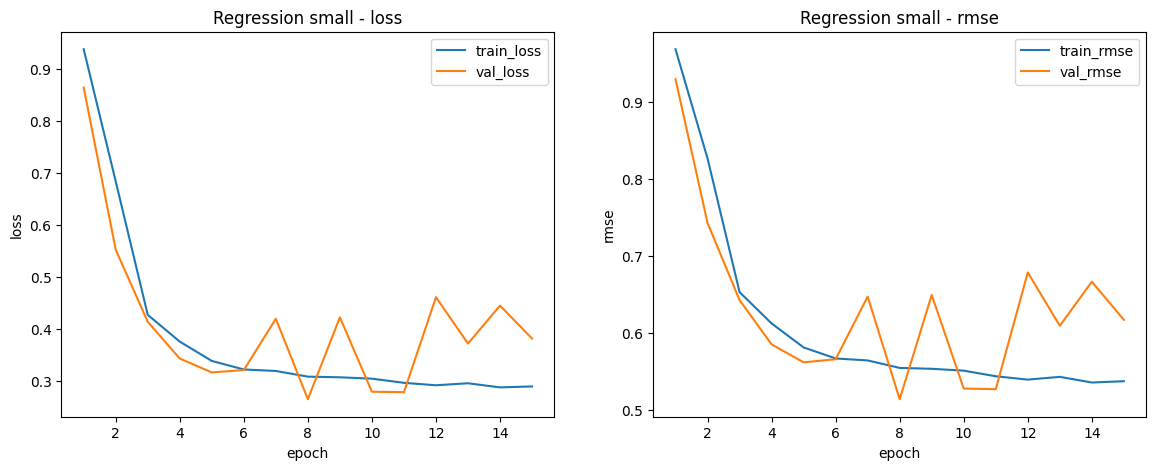


REGRESSION MODEL: MEDIUM
Epoch 01 | lr=0.000200 | train_loss=0.9227 | val_loss=0.8179 | train_rmse=0.9606 | val_rmse=0.9044
Epoch 02 | lr=0.000400 | train_loss=0.6051 | val_loss=0.4228 | train_rmse=0.7779 | val_rmse=0.6503
Epoch 03 | lr=0.000600 | train_loss=0.3892 | val_loss=0.3282 | train_rmse=0.6239 | val_rmse=0.5729
Epoch 04 | lr=0.000800 | train_loss=0.3510 | val_loss=0.3218 | train_rmse=0.5925 | val_rmse=0.5673
Epoch 05 | lr=0.001000 | train_loss=0.3197 | val_loss=0.3404 | train_rmse=0.5654 | val_rmse=0.5835
Epoch 06 | lr=0.001000 | train_loss=0.3104 | val_loss=0.4397 | train_rmse=0.5571 | val_rmse=0.6631
Epoch 07 | lr=0.001000 | train_loss=0.3028 | val_loss=0.2552 | train_rmse=0.5503 | val_rmse=0.5051
Epoch 08 | lr=0.001000 | train_loss=0.2870 | val_loss=0.3442 | train_rmse=0.5357 | val_rmse=0.5867
Epoch 09 | lr=0.001000 | train_loss=0.2879 | val_loss=0.3581 | train_rmse=0.5366 | val_rmse=0.5984
Epoch 10 | lr=0.000500 | train_loss=0.2809 | val_loss=0.2622 | train_rmse=0.5300 | 

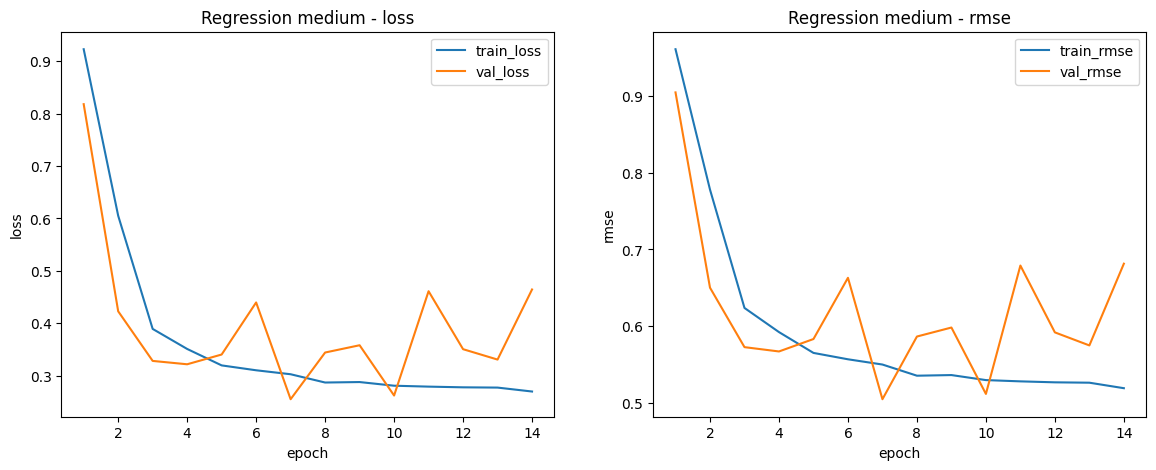


REGRESSION MODEL: LARGE
Epoch 01 | lr=0.000200 | train_loss=0.9331 | val_loss=0.8390 | train_rmse=0.9660 | val_rmse=0.9160
Epoch 02 | lr=0.000400 | train_loss=0.6447 | val_loss=0.4785 | train_rmse=0.8029 | val_rmse=0.6917
Epoch 03 | lr=0.000600 | train_loss=0.3972 | val_loss=0.3665 | train_rmse=0.6302 | val_rmse=0.6054
Epoch 04 | lr=0.000800 | train_loss=0.3345 | val_loss=0.3643 | train_rmse=0.5784 | val_rmse=0.6036
Epoch 05 | lr=0.001000 | train_loss=0.3197 | val_loss=0.2860 | train_rmse=0.5654 | val_rmse=0.5348
Epoch 06 | lr=0.001000 | train_loss=0.3066 | val_loss=0.2641 | train_rmse=0.5537 | val_rmse=0.5139
Epoch 07 | lr=0.001000 | train_loss=0.2936 | val_loss=0.2340 | train_rmse=0.5419 | val_rmse=0.4837
Epoch 08 | lr=0.001000 | train_loss=0.2885 | val_loss=0.4486 | train_rmse=0.5371 | val_rmse=0.6698
Epoch 09 | lr=0.001000 | train_loss=0.2855 | val_loss=0.3224 | train_rmse=0.5344 | val_rmse=0.5678
Epoch 10 | lr=0.001000 | train_loss=0.2795 | val_loss=0.2256 | train_rmse=0.5287 | v

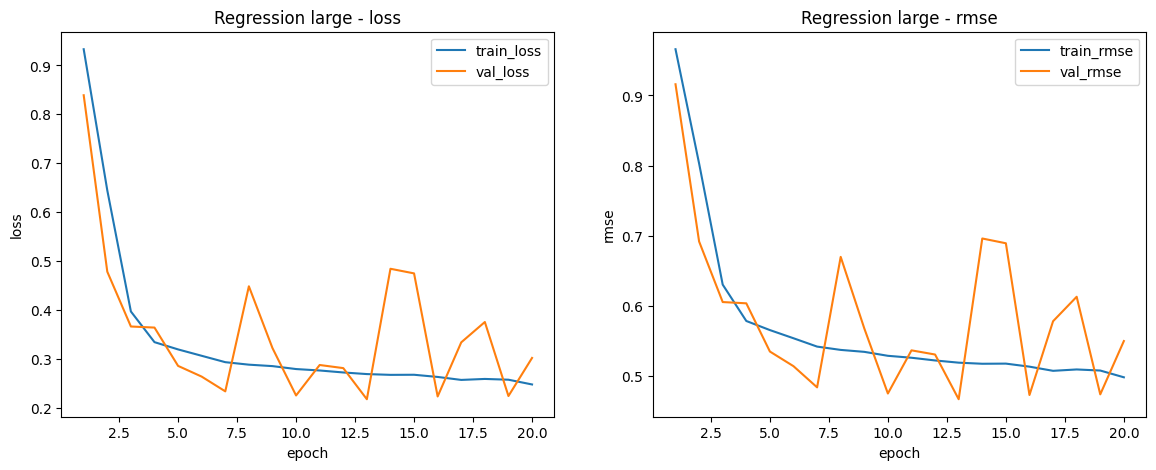

In [30]:
regression_results = {}

for size in ['small', 'medium', 'large']:
    print(f"\nREGRESSION MODEL: {size.upper()}")
    model = make_regression_model(
        size=size,
        activation='relu',
        input_dim=X_train.shape[1],
        output_dim=1
    )

    model, history = fit_regression_model(
        model,
        X_train, y_train,
        X_val, y_val,
        epochs=40,
        batch_size=128,
        optimizer_name='adam',
        lr=1e-3
    )

    test_loss, test_rmse = evaluate_regression(
        model, MSECriterion(), X_test, y_test, batch_size=128
    )

    print(f"TEST | loss={test_loss:.4f} | rmse={test_rmse:.4f}")

    regression_results[size] = {
        'model': model,
        'history': history,
        'test_loss': test_loss,
        'test_rmse': test_rmse
    }

    plot_history(history, title=f'Regression {size}')

## Классификация MNIST
В этом блоке:
- загружается датасет MNIST;
- изображения нормализуются;
- метки переводятся в one-hot формат;
- задается сверточная модель для мультиклассификации.

In [31]:
(X_train_full_mnist, y_train_full_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

X_train_mnist, X_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    X_train_full_mnist, y_train_full_mnist, test_size=0.1, random_state=42
)

X_train_mnist = (X_train_mnist.astype(np.float32) / 255.0)[:, None, :, :]
X_val_mnist = (X_val_mnist.astype(np.float32) / 255.0)[:, None, :, :]
X_test_mnist = (X_test_mnist.astype(np.float32) / 255.0)[:, None, :, :]

y_train_mnist_oh = one_hot_encode(y_train_mnist, 10).astype(np.float32)
y_val_mnist_oh = one_hot_encode(y_val_mnist, 10).astype(np.float32)
y_test_mnist_oh = one_hot_encode(y_test_mnist, 10).astype(np.float32)

print(X_train_mnist.shape, X_val_mnist.shape, X_test_mnist.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(54000, 1, 28, 28) (6000, 1, 28, 28) (10000, 1, 28, 28)


In [32]:
def make_mnist_model():
    model = Sequential()

    model.add(Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten())
    model.add(Linear(16 * 7 * 7, 128))
    model.add(BatchNormalization(alpha=0.9))
    model.add(ChannelwiseScaling(128))
    model.add(ReLU())
    model.add(Dropout(p=0.3))

    model.add(Linear(128, 10))
    model.add(LogSoftMax())

    return model

## Обучение классификатора MNIST
В этом блоке задается функция обучения сверточной сети, затем модель обучается и оценивается на тестовой выборке.

In [33]:
def fit_classification_model(
    model,
    X_train, y_train, y_train_oh,
    X_val, y_val, y_val_oh,
    epochs=10,
    batch_size=128,
    optimizer_name='adam',
    lr=1e-3
):
    criterion = ClassNLLCriterion()

    if optimizer_name.lower() == 'adam':
        optimizer = AdamOptimizer(model, lr=lr, weight_decay=1e-4)
    else:
        optimizer = SGDOptimizer(model, lr=lr, momentum=0.9, weight_decay=1e-4)

    warmup = WarmupScheduler(optimizer, warmup_epochs=3, target_lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=2, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, min_delta=1e-4)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        warmup.step(epoch)

        train_loss, train_acc = train_epoch_classification(
            model, criterion, optimizer,
            X_train, y_train, y_train_oh,
            batch_size=batch_size
        )

        val_loss, val_acc = evaluate_classification(
            model, criterion,
            X_val, y_val, y_val_oh,
            batch_size=batch_size
        )

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch {epoch+1:02d} | "
            f"lr={optimizer.lr:.6f} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
        )

        should_stop = early_stopping.step(val_loss, model)
        if should_stop:
            print("Early stopping!")
            break

    if early_stopping.best_params is not None:
        load_parameters(model, early_stopping.best_params)

    return model, history

## Автоэнкодер
В этом блоке задается автоэнкодер.
Энкодер построен на свертках, pooling, flatten и полносвязных слоях.
Декодер построен на полносвязных слоях.
Такой вариант подходит, если в первой части не реализованы ConvTranspose или upsampling-слои.

In [35]:
class AutoEncoder(Module):
    def __init__(self, latent_dim=32):
        super(AutoEncoder, self).__init__()

        self.encoder = Sequential()
        self.encoder.add(Conv2d(1, 8, kernel_size=3, stride=1, padding=1))
        self.encoder.add(ReLU())
        self.encoder.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

        self.encoder.add(Conv2d(8, 16, kernel_size=3, stride=1, padding=1))
        self.encoder.add(ReLU())
        self.encoder.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

        # важно: не схлопывать batch dimension
        self.encoder.add(Flatten(start_dim=1))
        self.encoder.add(Linear(16 * 7 * 7, 128))
        self.encoder.add(BatchNormalization(alpha=0.9))
        self.encoder.add(ChannelwiseScaling(128))
        self.encoder.add(ReLU())
        self.encoder.add(Dropout(p=0.2))
        self.encoder.add(Linear(128, latent_dim))

        self.decoder = Sequential()
        self.decoder.add(Linear(latent_dim, 128))
        self.decoder.add(BatchNormalization(alpha=0.9))
        self.decoder.add(ChannelwiseScaling(128))
        self.decoder.add(ReLU())
        self.decoder.add(Dropout(p=0.2))

        self.decoder.add(Linear(128, 16 * 7 * 7))
        self.decoder.add(ReLU())
        self.decoder.add(Linear(16 * 7 * 7, 28 * 28))
        self.decoder.add(SoftPlus())

    def updateOutput(self, input):
        z = self.encoder.forward(input)
        out = self.decoder.forward(z)
        self.output = out.reshape(input.shape[0], 1, 28, 28)
        return self.output

    def backward(self, input, gradOutput):
        grad = gradOutput.reshape(input.shape[0], -1)
        z = self.encoder.output
        grad = self.decoder.backward(z, grad)
        self.gradInput = self.encoder.backward(input, grad)
        return self.gradInput

    def __repr__(self):
        return "AutoEncoder"

## Обучение автоэнкодера
В этом блоке реализуется обучение автоэнкодера, оценка на тесте и визуализация реконструкций изображений.

Epoch 01 | lr=0.001000 | train_loss=0.412580 | val_loss=0.412991
Epoch 02 | lr=0.001000 | train_loss=0.412577 | val_loss=0.412991
Epoch 03 | lr=0.001000 | train_loss=0.412577 | val_loss=0.412988
Epoch 04 | lr=0.001000 | train_loss=0.412580 | val_loss=0.412987
Epoch 05 | lr=0.001000 | train_loss=0.412578 | val_loss=0.412987
AUTOENCODER TEST | recon_loss=0.416328


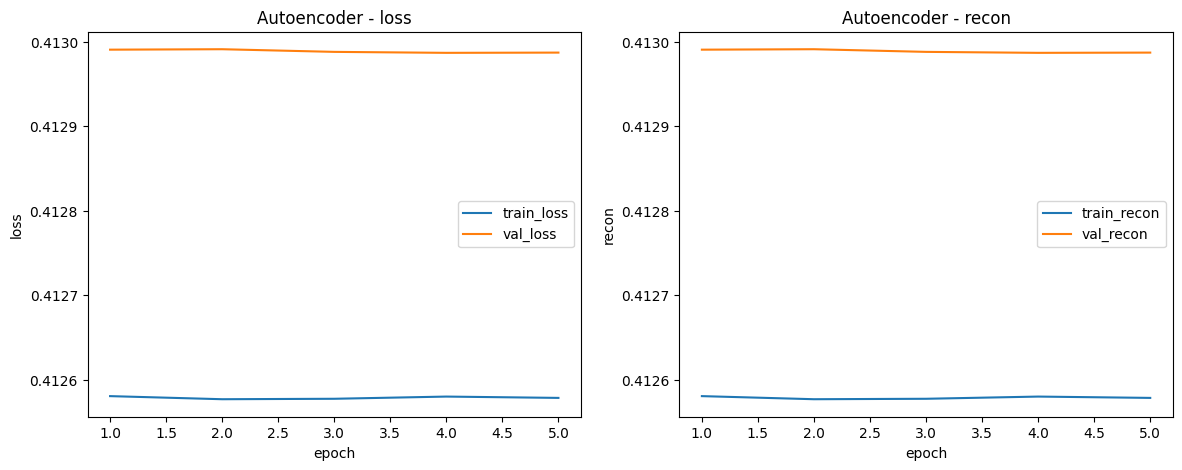

In [37]:
class AutoencoderMSECriterion(Criterion):
    def __init__(self):
        super(AutoencoderMSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.mean((input - target) ** 2)
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput = 2.0 * (input - target) / input.size
        return self.gradInput

    def __repr__(self):
        return "AutoencoderMSECriterion"


def train_epoch_autoencoder(model, criterion, optimizer, X, batch_size=128):
    set_train(model)
    total_loss = 0.0

    for X_batch in iterate_minibatches(X, batch_size=batch_size, shuffle=True):
        zero_grad(model)

        output = model.forward(X_batch)
        loss = criterion.forward(output, X_batch)
        grad_loss = criterion.backward(output, X_batch)

        model.backward(X_batch, grad_loss)
        optimizer.step()

        total_loss += loss * len(X_batch)

    return total_loss / len(X)


def evaluate_autoencoder(model, criterion, X, batch_size=128):
    set_eval(model)
    total_loss = 0.0

    for X_batch in iterate_minibatches(X, batch_size=batch_size, shuffle=False):
        output = model.forward(X_batch)
        loss = criterion.forward(output, X_batch)
        total_loss += loss * len(X_batch)

    return total_loss / len(X)


def fit_autoencoder(model, X_train, X_val, epochs=5, batch_size=128, lr=1e-3):
    criterion = AutoencoderMSECriterion()
    optimizer = AdamOptimizer(model, lr=lr, weight_decay=1e-4)

    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=2, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, min_delta=1e-5)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_recon': [],
        'val_recon': []
    }

    for epoch in range(epochs):
        train_loss = train_epoch_autoencoder(
            model, criterion, optimizer,
            X_train, batch_size=batch_size
        )

        val_loss = evaluate_autoencoder(
            model, criterion,
            X_val, batch_size=batch_size
        )

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_recon'].append(train_loss)
        history['val_recon'].append(val_loss)

        print(
            f"Epoch {epoch+1:02d} | "
            f"lr={optimizer.lr:.6f} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f}"
        )

        should_stop = early_stopping.step(val_loss, model)
        if should_stop:
            print("Early stopping!")
            break

    if early_stopping.best_params is not None:
        load_parameters(model, early_stopping.best_params)

    return model, history


# подвыборка для быстрого запуска
X_train_small = X_train_mnist[:5000]
X_val_small = X_val_mnist[:1000]
X_test_small = X_test_mnist[:1000]

autoencoder = AutoEncoder(latent_dim=32)

autoencoder, ae_history = fit_autoencoder(
    autoencoder,
    X_train_small,
    X_val_small,
    epochs=5,
    batch_size=128,
    lr=1e-3
)

ae_test_loss = evaluate_autoencoder(
    autoencoder,
    AutoencoderMSECriterion(),
    X_test_small,
    batch_size=128
)

print(f"AUTOENCODER TEST | recon_loss={ae_test_loss:.6f}")

plot_history(ae_history, title='Autoencoder')